In [1]:
import kagglehub
path = kagglehub.dataset_download("tli725/jl-corpus")
print("Path to dataset files:", path)

100%|██████████| 1.20G/1.20G [00:11<00:00, 111MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4


In [2]:
import os

def list_files_and_folders(startpath):
    for root, dirs, files in os.walk(startpath):
        print(f'{root}/')
        for f in files:
            print(f'{root}/{f}')

list_files_and_folders(path)

/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Corpus Setup.docx
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Recording Context.docx
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/README.md
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Raw JL corpus (unchecked and unannotated)/
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Raw JL corpus (unchecked and unannotated)/Word format_Human ethics form.doc
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Raw JL corpus (unchecked and unannotated)/Format_Intro.txt
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Raw JL corpus (unchecked and unannotated)/Proposal for speech databse recording_new.docx
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/Raw JL corpus (unchecked and unannotated)/Perception test material on Qualtrics/
/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/

In [3]:
import pandas as pd
audio_dir = "/root/.cache/kagglehub/datasets/tli725/jl-corpus/versions/4/raw jl corpus (unchecked and unannotated)/JL(wav+txt)/"

data = []
for file in os.listdir(audio_dir):
    if file.endswith(".wav"):
        label = file.split("_")[1]  # e.g., "angry"
        file_path = os.path.join(audio_dir, file)
        data.append({"file_path": file_path, "label": label})

df = pd.DataFrame(data)
print(df.head())

                                           file_path        label
0  /root/.cache/kagglehub/datasets/tli725/jl-corp...      neutral
1  /root/.cache/kagglehub/datasets/tli725/jl-corp...      anxious
2  /root/.cache/kagglehub/datasets/tli725/jl-corp...  encouraging
3  /root/.cache/kagglehub/datasets/tli725/jl-corp...   apologetic
4  /root/.cache/kagglehub/datasets/tli725/jl-corp...   apologetic


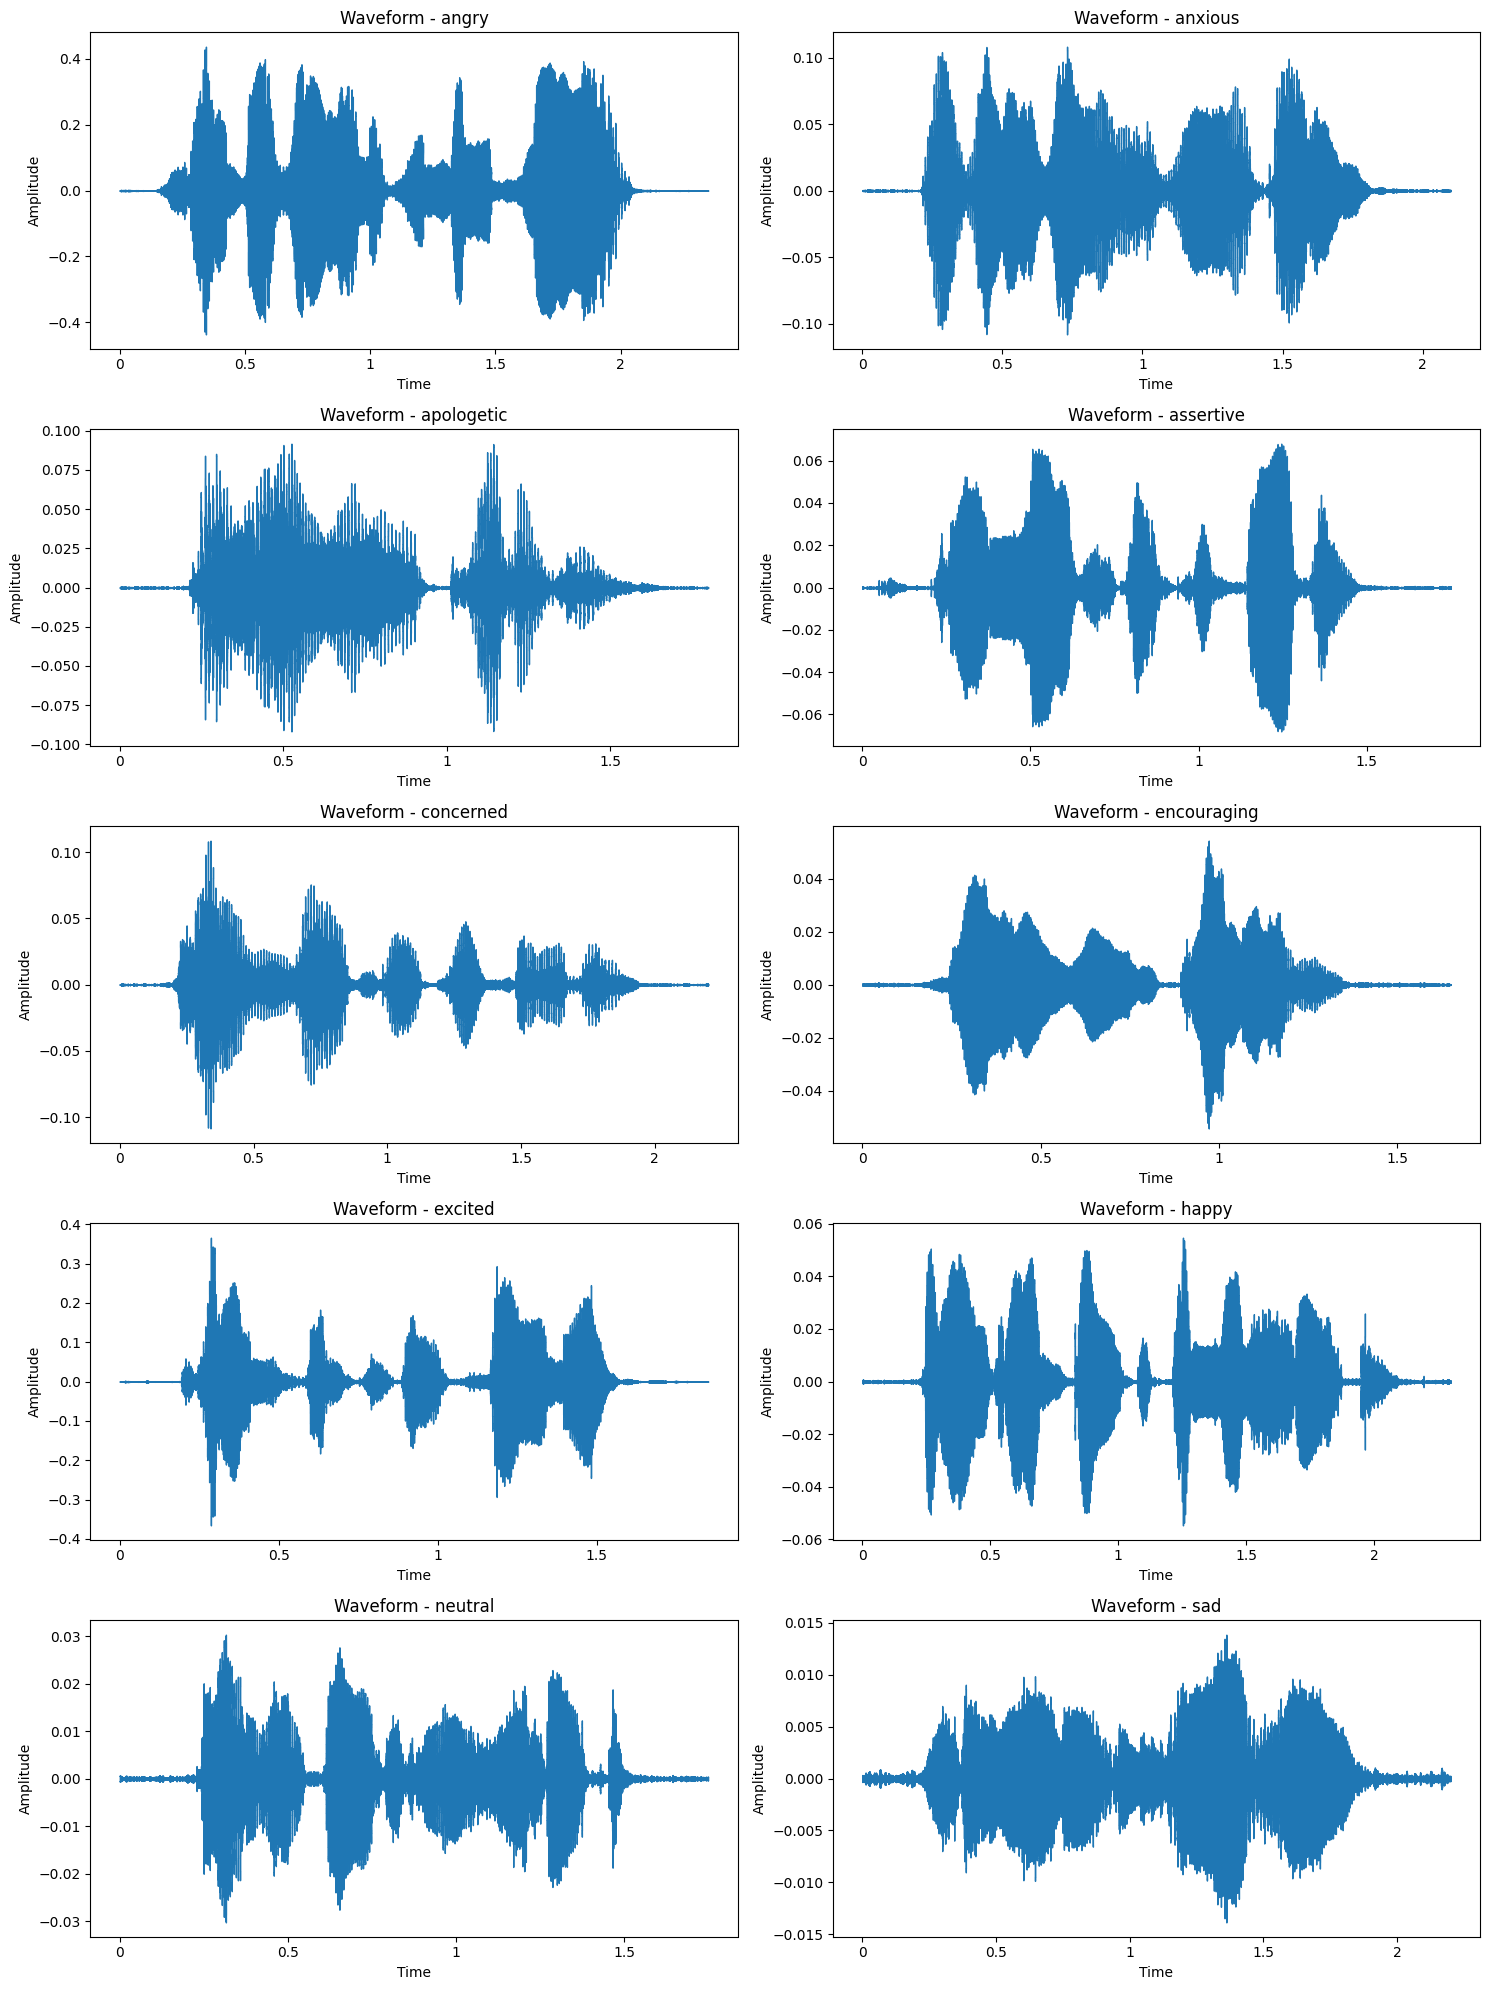

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Pick one sample per class
sample_df = df.groupby("label").first().reset_index()

plt.figure(figsize=(15, 20))
for i, row in enumerate(sample_df.itertuples(), 1):
    y, sr = librosa.load(row.file_path, sr=None)
    plt.subplot(5, 2, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {row.label}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [5]:
class_counts = df['label'].value_counts()
print("Sample count per class:\n")
for label, count in class_counts.items():
    print(f"{label}: {count} samples")

Sample count per class:

neutral: 240 samples
anxious: 240 samples
encouraging: 240 samples
apologetic: 240 samples
sad: 240 samples
assertive: 240 samples
happy: 240 samples
concerned: 240 samples
excited: 240 samples
angry: 240 samples


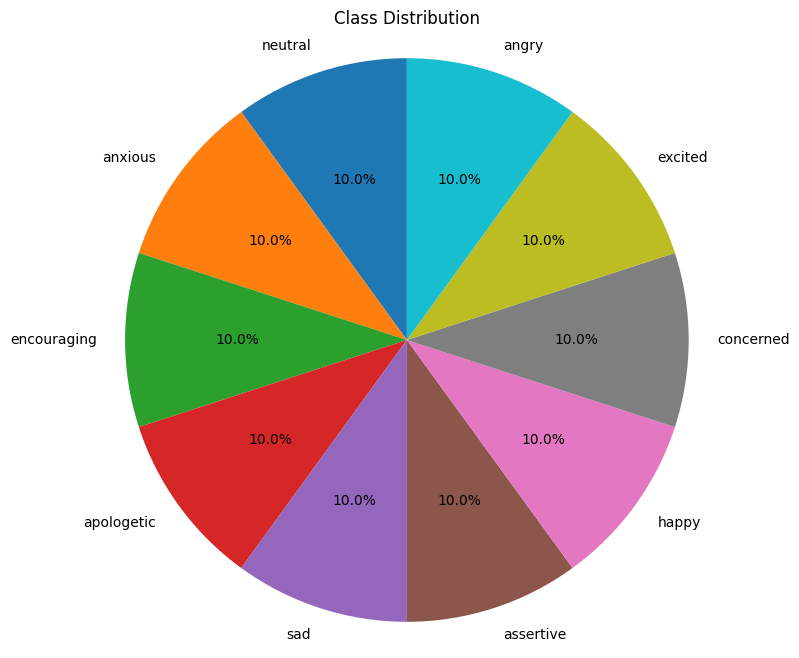

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Class Distribution")
plt.axis('equal')
plt.show()

In [7]:
import librosa
from tqdm import tqdm  # For progress bar

durations = []

for path in tqdm(df['file_path']):
    try:
        y, sr = librosa.load(path, sr=None)  # Use original sampling rate
        duration = librosa.get_duration(y=y, sr=sr)
        durations.append(duration)
    except Exception as e:
        print(f"Error processing {path}: {e}")
        durations.append(None)

df['duration'] = durations

100%|██████████| 2400/2400 [00:00<00:00, 2517.37it/s]


In [8]:
print(df['duration'].describe())

count    2400.000000
mean        2.118012
std         0.327242
min         1.200000
25%         1.900000
50%         2.100000
75%         2.300000
max         3.750000
Name: duration, dtype: float64


In [9]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.0/996.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.9/324.9 kB 29.0 MB/s eta 0:00:00


In [10]:
import numpy as np
import librosa
from opensmile import Smile, FeatureSet, FeatureLevel

# Create OpenSMILE extractor for HNR, jitter, shimmer
smile_extractor = Smile(
    feature_set=FeatureSet.eGeMAPSv02,
    feature_level=FeatureLevel.Functionals
)
target_smile_columns = [
    'jitterLocal_sma3nz_amean',
    'shimmerLocaldB_sma3nz_amean',
    'HNRdBACF_sma3nz_amean'
]

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        features = []

        # MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        features.extend(np.mean(mfcc, axis=1))
        features.extend(np.std(mfcc, axis=1))

        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        features.extend(np.mean(delta, axis=1))
        features.extend(np.std(delta, axis=1))
        features.extend(np.mean(delta2, axis=1))
        features.extend(np.std(delta2, axis=1))

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))
        features.extend(np.std(chroma, axis=1))

        # Spectral Centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features.append(np.mean(centroid))
        features.append(np.std(centroid))

        # Spectral Rolloff
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features.append(np.mean(rolloff))
        features.append(np.std(rolloff))

        # Spectral Bandwidth
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        features.append(np.mean(bandwidth))
        features.append(np.std(bandwidth))

        # Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        features.extend(np.mean(contrast, axis=1))
        features.extend(np.std(contrast, axis=1))

        # Pitch
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitch_values = pitches[magnitudes > np.median(magnitudes)]
        if pitch_values.size > 0:
            features.append(np.mean(pitch_values))
            features.append(np.std(pitch_values))
        else:
            features.extend([0, 0])

        # Tempo
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(tempo)

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))

        # RMS Energy
        rms = librosa.feature.rms(y=y)
        features.append(np.mean(rms))
        features.append(np.std(rms))

        smile_df = smile_extractor.process_file(file_path)
        smile_selected = [smile_df[col].values[0] if col in smile_df.columns else 0.0 for col in target_smile_columns]
        features.extend(smile_selected)

        return [float(f.item() if isinstance(f, np.ndarray) else f) for f in features]

    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return [0] * 132

In [11]:
from tqdm import tqdm

feature_list = []
error_indices = []

for i, path in enumerate(tqdm(df['file_path'])):
    feats = extract_features(path)
    if isinstance(feats, list) and len(feats) == 132:
        feature_list.append(feats)
    else:
        error_indices.append(i)
        print(f" Feature shape issue at index {i}, length = {len(feats) if feats else 'None'}")

100%|██████████| 2400/2400 [07:09<00:00,  5.58it/s]


In [12]:
X = np.array(feature_list, dtype=np.float32)
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (2400, 132)


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['label'])
print("Labels shape:", y.shape)

Labels shape: (2400,)


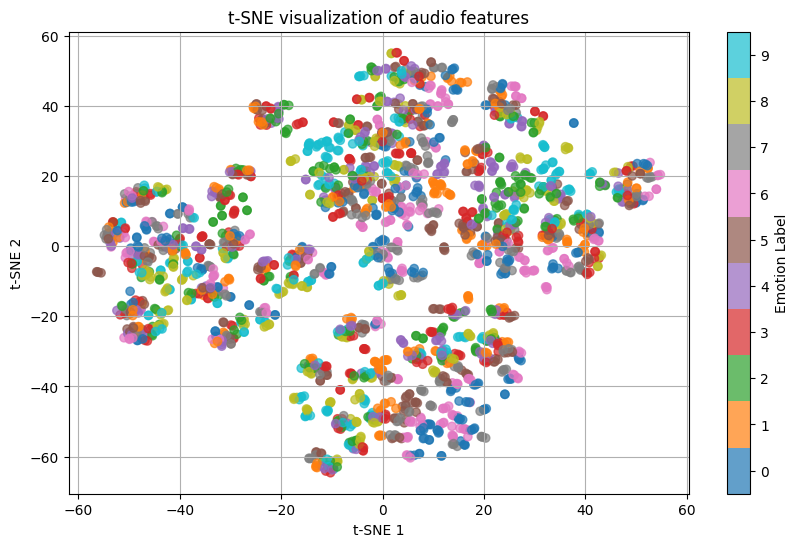

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title("t-SNE visualization of audio features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, ticks=range(len(le.classes_)), label="Emotion Label")
plt.clim(-0.5, len(le.classes_)-0.5)
plt.grid(True)
plt.show()

In [15]:
!pip install shap

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Emotion labels
emotion_labels = le.classes_

# feature names
feature_names = []
for i in range(13): feature_names += [f'mfcc_mean_{i}', f'mfcc_std_{i}']
for i in range(13): feature_names += [f'delta_mean_{i}', f'delta_std_{i}']
for i in range(13): feature_names += [f'delta2_mean_{i}', f'delta2_std_{i}']
for i in range(12): feature_names += [f'chroma_mean_{i}', f'chroma_std_{i}']
feature_names += ['spectral_centroid_mean', 'spectral_centroid_std']
feature_names += ['spectral_rolloff_mean', 'spectral_rolloff_std']
feature_names += ['spectral_bandwidth_mean', 'spectral_bandwidth_std']
for i in range(7): feature_names += [f'spectral_contrast_mean_{i}', f'spectral_contrast_std_{i}']
feature_names += ['pitch_mean', 'pitch_std', 'tempo', 'zcr_mean', 'zcr_std', 'rms_mean', 'rms_std']
feature_names += ['jitter_local_mean', 'shimmer_localdB_mean', 'hnr_dBACF_mean']

print("Total features:", len(feature_names))

Total features: 132


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [2, 4, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Run GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [18]:
import joblib

# Save the feature matrix and label array
joblib.dump(X, "X_features.pkl")
joblib.dump(y, "y_labels.pkl")

print("Saved X and y successfully.")

Saved X and y successfully.


In [19]:
from google.colab import files
files.download("X_features.pkl")
files.download("y_labels.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>